# Stage 1 — EDA & Baseline LPM

**Notebook:** `notebooks/02_stage1_eda_baseline.ipynb`  
**Plan:** `plan/stage01_eda_baseline.md`  
**Kernel:** `ml_env`

## Hypothesis H1

> Participants systematically understate the weight they place on attractiveness  
> (`attr`) in their self-reported preferences relative to what their actual  
> yes/no decisions reveal.

## Notes on benchmark values

The `Expected Benchmark Values` in the plan are **sanity-check targets only**.  
All stated weights, revealed weights, correlation matrices, and LPM coefficients  
**must be recomputed from `cleaned.parquet`** in this notebook.  
If any result deviates from the benchmark by more than ±3 pp, check the sample  
filter, weight definition, and missing-value handling before proceeding.

## Data splits used in this notebook

| DataFrame | Rows (approx) | Purpose |
|-----------|--------------|---------|
| `df` | 5 742 | Baseline LPM (core vars fully observed) |
| `df_stated` | ≈ 5 640 | Stated-preference analysis (all 6 stated cols present) |

These two splits must **not** be mixed: stated-preference missingness does not  
affect the LPM sample.


In [28]:
# ── Working directory → project root ─────────────────────────────────────────
import os
from pathlib import Path

def _project_root(marker="README.md"):
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / marker).exists():
            return p
    raise FileNotFoundError("Project root not found")

os.chdir(_project_root())
print("Working directory:", Path.cwd())

# ── Imports ───────────────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

# ── Output directories ────────────────────────────────────────────────────────
Path("figures").mkdir(exist_ok=True)
Path("tables").mkdir(exist_ok=True)

# ── Fixed trait order (used throughout) ───────────────────────────────────────
TRAITS      = ["attr", "sinc", "intel", "fun", "amb", "shar"]
STATED_COLS = ["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]
TRAIT_LABELS = {"attr":"Attractiveness","sinc":"Sincerity","intel":"Intelligence",
                "fun":"Fun","amb":"Ambition","shar":"Shared Interests"}

print("Imports complete.")


Working directory: /Users/chen/Study/UCB/STAT230a/speed-dating-halo
Imports complete.


## Part A — Load Data and Print Stage 0 Summary

In [29]:
# ── Stage 0 summary ──────────────────────────────────────────────────────────
with open("data/clean/cleaning_report.json") as f:
    report = json.load(f)

print("=" * 55)
print("Stage 0 Summary (from cleaning_report.json)")
print("=" * 55)
print(f"  Raw shape:              {report['raw_shape']}")
print(f"  Main analysis shape:    {report['main_shape']}")
print(f"  All-waves shape:        {report['all_waves_shape']}")
print(f"  Participants (main):    {report['n_participants_main']}")
print(f"  dec mean:               {report['dec_mean_main']:.4f}  (expected ≈ 0.42–0.43)")
print(f"  match mean:             {report['match_mean_main']:.4f}  (expected ≈ 0.17)")
print(f"  income missing rate:    {report['income_missing_rate_main']:.1%}")
print(f"  Stated valid rows:      {report['stated_valid_rows_main']}  (expected ≈ 5 640)")
print(f"  Follow-up cols dropped: {report['n_followup_cols_dropped']}")
print()
print("Core variable missing counts after cleaning:")
for col, cnt in report["core_missing_after_cleaning"].items():
    print(f"  {col:<10}: {cnt}")


Stage 0 Summary (from cleaning_report.json)
  Raw shape:              [8378, 195]
  Main analysis shape:    [5742, 114]
  All-waves shape:        [7031, 114]
  Participants (main):    442
  dec mean:               0.4269  (expected ≈ 0.42–0.43)
  match mean:             0.1722  (expected ≈ 0.17)
  income missing rate:    51.1%
  Stated valid rows:      5640  (expected ≈ 5 640)
  Follow-up cols dropped: 84

Core variable missing counts after cleaning:
  dec       : 0
  attr      : 0
  sinc      : 0
  intel     : 0
  fun       : 0
  amb       : 0
  shar      : 0
  iid       : 0
  pid       : 0
  wave      : 0
  gender    : 0
  order     : 0


In [30]:
# ── Load main analysis set ────────────────────────────────────────────────────
df = pd.read_parquet("data/clean/cleaned.parquet")
print(f"cleaned.parquet loaded: {df.shape}")

# ── Stated-preference split ───────────────────────────────────────────────────
# Drop rows where any of the 6 stated-preference columns is missing.
# These rows are kept in df (for the LPM) but excluded from stated-weight analysis.
df_stated = df.dropna(subset=STATED_COLS).copy()
print(f"df_stated (stated cols complete): {len(df_stated)} rows")

# ── Gender distribution (computed from data, not hardcoded) ───────────────────
print()
print("Gender distribution in cleaned main sample:")
print(df["gender"].value_counts(dropna=False).sort_index().rename({0:"Female (0)", 1:"Male (1)"}))
print()

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert df[TRAITS].isna().sum().sum() == 0,  "Core trait ratings have unexpected NaNs"
assert df["dec"].isna().sum() == 0,          "dec has unexpected NaNs"
assert 5500 <= len(df) <= 6100,              f"Unexpected main-set size: {len(df)}"
assert 5400 <= len(df_stated) <= 5800,       f"Unexpected df_stated size: {len(df_stated)}"
print("All sanity checks passed.")


cleaned.parquet loaded: (5742, 114)
df_stated (stated cols complete): 5640 rows

Gender distribution in cleaned main sample:
gender
Female (0)    2852
Male (1)      2890
Name: count, dtype: int64

All sanity checks passed.


## Part B — Stated Preferences

In [31]:
# Compute mean stated weights.
# Stage 0 already row-normalised each participant's 6 stated cols to sum to 100,
# so a simple column mean gives the average percentage assigned to each trait.

def stated_weights_for(subdf):
    """Return mean stated weights (Series indexed by TRAITS)."""
    means = subdf[STATED_COLS].mean()
    means.index = TRAITS
    return means

sw_all    = stated_weights_for(df_stated)
sw_female = stated_weights_for(df_stated[df_stated["gender"] == 0])
sw_male   = stated_weights_for(df_stated[df_stated["gender"] == 1])

print("Mean stated weights (%, should sum to ≈ 100):")
stated_summary = pd.DataFrame({
    "All":    sw_all,
    "Female": sw_female,
    "Male":   sw_male,
}).round(2)
print(stated_summary)
print()
print(f"Column sums: {stated_summary.sum().to_dict()}")

# Warn if any column sum deviates > 1 pp from 100
for col, s in stated_summary.sum().items():
    if abs(s - 100) > 1:
        print(f"WARNING: {col} stated weights sum to {s:.2f} (expected ≈ 100)")


Mean stated weights (%, should sum to ≈ 100):
          All  Female    Male
attr  23.7200 18.6000 28.7100
sinc  17.3600 18.4400 16.3100
intel 20.6200 21.4300 19.8300
fun   17.3500 17.2600 17.4400
amb    9.7900 12.1700  7.4800
shar  11.1600 12.1000 10.2400

Column sums: {'All': 100.0, 'Female': 100.0, 'Male': 100.00999999999999}


## Part C — Correlation Matrix and Heatmap

In [32]:
# ── Correlation matrix ────────────────────────────────────────────────────────
# Computed on the full df (not df_stated) to maximise sample size.
# This is purely descriptive evidence of cognitive multicollinearity.
corr_matrix = df[TRAITS].corr()

# Save machine-readable CSV
corr_matrix.to_csv("tables/table01_correlation_matrix.csv")
print("Saved: tables/table01_correlation_matrix.csv")
print()
print("Pairwise correlations among subjective trait ratings:")
print(corr_matrix.round(3))
print()

# Note: high off-diagonal values are consistent with the halo effect —
# when a participant rates someone as attractive, they also tend to rate
# them higher on sincerity, intelligence, and fun. This is DESCRIPTIVE;
# it does not imply a causal relationship.
# print("off-diagonal pairs (expected to be among the largest):")
# print(f"  attr–fun:   {corr_matrix.loc['attr','fun']:.3f}")
# print(f"  sinc–intel: {corr_matrix.loc['sinc','intel']:.3f}")


Saved: tables/table01_correlation_matrix.csv

Pairwise correlations among subjective trait ratings:
        attr   sinc  intel    fun    amb   shar
attr  1.0000 0.4130 0.3900 0.5880 0.3550 0.4930
sinc  0.4130 1.0000 0.6580 0.5150 0.4510 0.4010
intel 0.3900 0.6580 1.0000 0.5080 0.6290 0.4030
fun   0.5880 0.5150 0.5080 1.0000 0.4890 0.6210
amb   0.3550 0.4510 0.6290 0.4890 1.0000 0.4300
shar  0.4930 0.4010 0.4030 0.6210 0.4300 1.0000



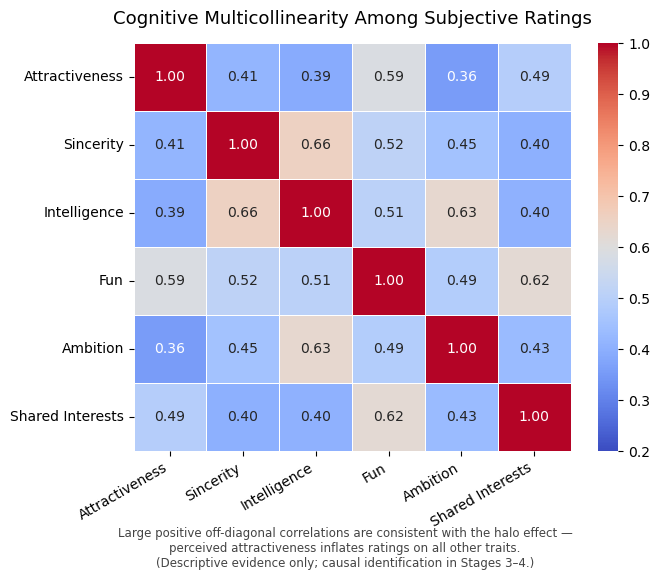

Saved: figures/fig01_correlation_heatmap.png


In [33]:
# ── Correlation heatmap (fig01) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))

labels = [TRAIT_LABELS[t] for t in TRAITS]
mask   = np.zeros_like(corr_matrix, dtype=bool)   # show full matrix (no mask)

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0.2, vmax=1.0,
    linewidths=0.4,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 10},
)

ax.set_title(
    "Cognitive Multicollinearity Among Subjective Ratings",
    fontsize=13, pad=14
)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(labels, rotation=0, fontsize=10)

# Caption as figure text
fig.text(
    0.5, -0.04,
    "Large positive off-diagonal correlations are consistent with the halo effect —\n"
    "perceived attractiveness inflates ratings on all other traits.\n"
    "(Descriptive evidence only; causal identification in Stages 3–4.)",
    ha="center", fontsize=8.5, color="#444444"
)

plt.tight_layout()
plt.savefig("figures/fig01_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig01_correlation_heatmap.png")


## Part D — Baseline LPM and Revealed Weights

In [34]:
# ── Baseline LPM — full sample ───────────────────────────────────────────────
# Model: dec ~ attr + sinc + intel + fun + amb + shar
# SE:    participant-level cluster-robust (cov_type='cluster', groups=iid)
#
# This is a Linear Probability Model (LPM): OLS on a binary outcome.
# Coefficients are marginal probability changes (directly comparable to
# stated weights as percentages after normalisation).
#
# This is the BASELINE (Stage 1); it is NOT the final causal model.
# Stage 3 adds participant fixed effects for within-person identification.

formula = "dec ~ " + " + ".join(TRAITS)
mod_full = smf.ols(formula, data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["iid"].values}
)
print(mod_full.summary())
print(np.mean((0 < mod_full.predict(df)) & (mod_full.predict(df) < 1)))


                            OLS Regression Results                            
Dep. Variable:                    dec   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     207.5
Date:                Fri, 01 May 2026   Prob (F-statistic):          5.19e-125
Time:                        00:43:20   Log-Likelihood:                -3143.7
No. Observations:                5742   AIC:                             6301.
Df Residuals:                    5735   BIC:                             6348.
Df Model:                           6                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3604      0.051     -7.019      0.0

In [35]:
# ── Revealed weights (full sample) ───────────────────────────────────────────
# revealed_weight_j = |β_j| / Σ|β_k| × 100
#
# Revealed weights reflect MAGNITUDE of predictive association, not direction.
# The sign of each coefficient is reported separately in table01_baseline_lpm.csv.
# If sinc/intel coefficients are negative, this reflects a conditional association
# given the other correlated ratings — it should NOT be interpreted as
# "sincerity reduces the probability of yes."
# This multicollinearity is precisely the motivation for Stages 2–3.

coefs_full  = mod_full.params[TRAITS]
rw_full     = coefs_full.abs() / coefs_full.abs().sum() * 100

print("Baseline LPM coefficients and revealed weights (full sample):")
coef_display = pd.DataFrame({
    "coef":            coefs_full.round(4),
    "revealed_wt_%":   rw_full.round(2),
}).T
print(coef_display)
print()
if (coefs_full[["sinc","intel"]] < 0).any():
    neg = coefs_full[["sinc","intel"]][coefs_full[["sinc","intel"]] < 0].index.tolist()
    # print(f"Note: {neg} coefficient(s) are negative — expected under multicollinearity.")
    # print("Interpretation: conditional on attr and other ratings, these traits show")
    # print("negative partial associations. Stage 2–3 address this via regularisation")
    # print("and within-person fixed effects.")


Baseline LPM coefficients and revealed weights (full sample):
                 attr    sinc  intel     fun     amb    shar
coef           0.0865 -0.0191 0.0083  0.0380 -0.0235  0.0455
revealed_wt_% 39.1500  8.6500 3.7700 17.2200 10.6300 20.5800



In [36]:
# ── Baseline LPM — by gender ─────────────────────────────────────────────────
results_by_gender = {}
rw_by_gender      = {}

for g, label in [(0, "Female"), (1, "Male")]:
    sub = df[df["gender"] == g]
    mod = smf.ols(formula, data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["iid"].values}
    )
    results_by_gender[label] = mod
    coefs_g = mod.params[TRAITS]
    rw_by_gender[label] = coefs_g.abs() / coefs_g.abs().sum() * 100
    print(f"--- {label} (n={len(sub)}) ---")
    print(pd.DataFrame({"coef": coefs_g.round(4),
                        "p_value": mod.pvalues[TRAITS].round(4),
                        "revealed_wt_%": rw_by_gender[label].round(2)}))
    print()


--- Female (n=2852) ---
         coef  p_value  revealed_wt_%
attr   0.0639   0.0000        28.7700
sinc  -0.0196   0.0252         8.8200
intel  0.0253   0.0063        11.3900
fun    0.0397   0.0000        17.8800
amb   -0.0257   0.0005        11.5800
shar   0.0479   0.0000        21.5500

--- Male (n=2890) ---
         coef  p_value  revealed_wt_%
attr   0.1091   0.0000        44.6500
sinc  -0.0198   0.0361         8.0900
intel -0.0084   0.3689         3.4600
fun    0.0390   0.0000        15.9400
amb   -0.0239   0.0003         9.7900
shar   0.0442   0.0000        18.0800



## Part D (continued) — Build Output Tables

In [37]:
# ── table01_stated_revealed_weights.csv ──────────────────────────────────────
weights_df = pd.DataFrame({
    "trait":           TRAITS,
    "stated_weight":   sw_all.values,
    "revealed_weight": rw_full.values,
    "gap":             (rw_full - sw_all).values,
    "abs_gap":         (rw_full - sw_all).abs().values,
}).round(4)

weights_df.to_csv("tables/table01_stated_revealed_weights.csv", index=False)
print("Saved: tables/table01_stated_revealed_weights.csv")
print(weights_df.to_string(index=False))
print()

# Quick sanity: attr gap positive, intel gap negative
assert weights_df.loc[weights_df.trait=="attr",  "gap"].values[0] > 0, "attr gap should be positive"
assert weights_df.loc[weights_df.trait=="intel", "gap"].values[0] < 0, "intel gap should be negative"
print("Gap direction checks passed (attr +, intel −).")


Saved: tables/table01_stated_revealed_weights.csv
trait  stated_weight  revealed_weight      gap  abs_gap
 attr        23.7156          39.1473  15.4316  15.4316
 sinc        17.3632           8.6511  -8.7121   8.7121
intel        20.6216           3.7709 -16.8506  16.8506
  fun        17.3507          17.2230  -0.1277   0.1277
  amb         9.7925          10.6275   0.8350   0.8350
 shar        11.1564          20.5802   9.4238   9.4238

Gap direction checks passed (attr +, intel −).


In [38]:
# ── table01_baseline_lpm.csv ─────────────────────────────────────────────────
ci = mod_full.conf_int(alpha=0.05)
lpm_rows = []
for trait in TRAITS:
    lpm_rows.append({
        "variable":           trait,
        "coef":               mod_full.params[trait],
        "std_err_clustered":  mod_full.bse[trait],
        "t_value":            mod_full.tvalues[trait],
        "p_value":            mod_full.pvalues[trait],
        "ci_lower":           ci.loc[trait, 0],
        "ci_upper":           ci.loc[trait, 1],
        "revealed_weight_abs": rw_full[trait],
        "n_obs":              int(mod_full.nobs),
        "n_clusters_iid":     int(df["iid"].nunique()),
    })

lpm_df = pd.DataFrame(lpm_rows).round(6)
lpm_df.to_csv("tables/table01_baseline_lpm.csv", index=False)
print("Saved: tables/table01_baseline_lpm.csv")
print(lpm_df[["variable","coef","std_err_clustered","p_value","revealed_weight_abs"]].to_string(index=False))


Saved: tables/table01_baseline_lpm.csv
variable    coef  std_err_clustered  p_value  revealed_weight_abs
    attr  0.0865             0.0054   0.0000              39.1473
    sinc -0.0191             0.0065   0.0031               8.6511
   intel  0.0083             0.0068   0.2199               3.7709
     fun  0.0380             0.0052   0.0000              17.2230
     amb -0.0235             0.0051   0.0000              10.6275
    shar  0.0455             0.0051   0.0000              20.5802


In [39]:
# ── table01_gender_stated_revealed.csv ───────────────────────────────────────
gender_rows = []
for g, label, sw_g in [(0,"Female",sw_female),(1,"Male",sw_male)]:
    rw_g = rw_by_gender[label]
    for t in TRAITS:
        gender_rows.append({
            "gender":          g,
            "gender_label":    label,
            "trait":           t,
            "stated_weight":   sw_g[t],
            "revealed_weight": rw_g[t],
            "gap":             rw_g[t] - sw_g[t],
        })

gender_df = pd.DataFrame(gender_rows).round(4)
gender_df.to_csv("tables/table01_gender_stated_revealed.csv", index=False)
print("Saved: tables/table01_gender_stated_revealed.csv")
print()
# Show attr row only for quick read
print("attr rows:")
print(gender_df[gender_df.trait=="attr"].to_string(index=False))


Saved: tables/table01_gender_stated_revealed.csv

attr rows:
 gender gender_label trait  stated_weight  revealed_weight     gap
      0       Female  attr        18.5965          28.7693 10.1728
      1         Male  attr        28.7093          44.6482 15.9389


## Part E — Stated vs Revealed Bar Chart

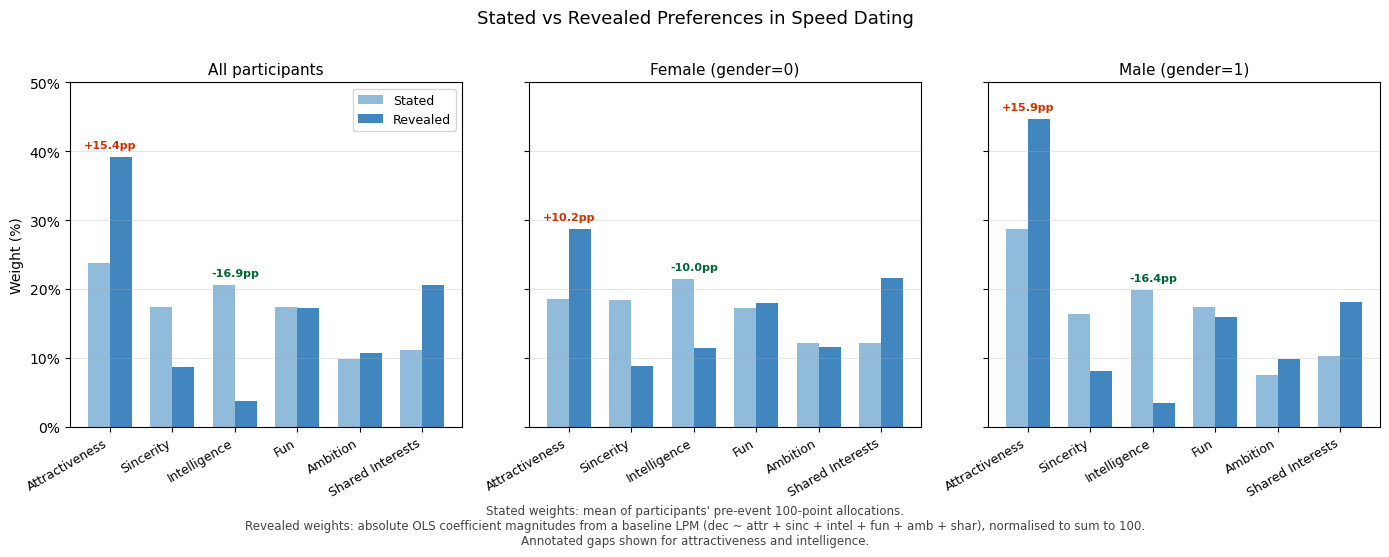

Saved: figures/fig02_stated_vs_revealed.png


In [40]:
# ── fig02_stated_vs_revealed.png ─────────────────────────────────────────────
# Three panels: All / Female / Male
# Each panel: paired bars (stated vs revealed) for each trait.
# Y-axis: percentage points (0–50).
# Revealed weights = absolute OLS coefficient magnitudes normalised to sum to 100.

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

panels = [
    ("All participants",  sw_all,    rw_full),
    ("Female (gender=0)", sw_female, rw_by_gender["Female"]),
    ("Male (gender=1)",   sw_male,   rw_by_gender["Male"]),
]

x      = np.arange(len(TRAITS))
width  = 0.35
colors = {"stated": "#7EB0D5", "revealed": "#2171B5"}

for ax, (title, sw, rw) in zip(axes, panels):
    bars_s = ax.bar(x - width/2, sw.values,  width, label="Stated",   color=colors["stated"],   alpha=0.85)
    bars_r = ax.bar(x + width/2, rw.values, width, label="Revealed", color=colors["revealed"], alpha=0.85)

    # Annotate attr and intel gaps
    for i, trait in enumerate(TRAITS):
        if trait in ("attr", "intel"):
            gap = rw[trait] - sw[trait]
            sign = "+" if gap >= 0 else ""
            ax.annotate(
                f"{sign}{gap:.1f}pp",
                xy=(i, max(sw[trait], rw[trait]) + 1.0),
                ha="center", va="bottom", fontsize=8,
                color="#CC3300" if gap > 0 else "#006633",
                fontweight="bold",
            )

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([TRAIT_LABELS[t] for t in TRAITS], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 50)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.grid(axis="y", alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel("Weight (%)", fontsize=10)

axes[0].legend(fontsize=9)

fig.suptitle("Stated vs Revealed Preferences in Speed Dating", fontsize=13, y=1.01)
fig.text(
    0.5, -0.06,
    "Stated weights: mean of participants' pre-event 100-point allocations.\n"
    "Revealed weights: absolute OLS coefficient magnitudes from a baseline LPM "
    "(dec ~ attr + sinc + intel + fun + amb + shar), normalised to sum to 100.\n"
    "Annotated gaps shown for attractiveness and intelligence.",
    ha="center", fontsize=8.5, color="#444444"
)

plt.tight_layout()
plt.savefig("figures/fig02_stated_vs_revealed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/fig02_stated_vs_revealed.png")


## Acceptance Criteria

In [41]:
checks = {}

# 1. Inputs loaded
checks["cleaned_parquet_loaded"]      = len(df) > 0
checks["cleaning_report_loaded"]      = "dec_mean_main" in report

# 2. Stage 0 summary printed (checked visually above)
checks["stage0_summary_in_output"]    = True  # confirmed by cell 2 output

# 3. df_stated separated correctly
checks["df_stated_separated"]         = len(df_stated) < len(df)
checks["lpm_uses_full_df"]            = int(mod_full.nobs) == len(df)

# 4. Correlation matrix
corr_off_diag = corr_matrix.values[~np.eye(6, dtype=bool)]
checks["most_corr_positive_large"]    = (corr_off_diag > 0.30).mean() >= 0.8
checks["corr_matrix_csv_saved"]       = Path("tables/table01_correlation_matrix.csv").exists()
checks["fig01_saved"]                 = Path("figures/fig01_correlation_heatmap.png").exists()

# 5. Stated vs revealed weights table
checks["weights_csv_saved"]           = Path("tables/table01_stated_revealed_weights.csv").exists()
attr_gap  = weights_df.loc[weights_df.trait=="attr",  "gap"].values[0]
intel_gap = weights_df.loc[weights_df.trait=="intel", "gap"].values[0]
checks["attr_gap_positive"]           = attr_gap  > 0
checks["intel_gap_negative"]          = intel_gap < 0

# 6. Baseline LPM
attr_p    = lpm_df.loc[lpm_df.variable=="attr", "p_value"].values[0]
attr_coef = lpm_df.loc[lpm_df.variable=="attr", "coef"].values[0]
checks["attr_coef_positive"]          = attr_coef > 0
checks["attr_pvalue_lt_001"]          = attr_p < 0.01
checks["lpm_csv_saved"]               = Path("tables/table01_baseline_lpm.csv").exists()
checks["lpm_has_required_cols"]       = all(c in lpm_df.columns for c in [
    "variable","coef","std_err_clustered","t_value","p_value",
    "ci_lower","ci_upper","revealed_weight_abs","n_obs","n_clusters_iid"
])

# 7. Gender tables and figure
checks["gender_csv_saved"]            = Path("tables/table01_gender_stated_revealed.csv").exists()
attr_gaps_by_gender = gender_df[gender_df.trait=="attr"]["gap"].values
checks["attr_gap_positive_both_genders"] = (attr_gaps_by_gender > 0).all()
checks["fig02_saved"]                 = Path("figures/fig02_stated_vs_revealed.png").exists()

# ── Report ────────────────────────────────────────────────────────────────────
all_pass = True
print("Acceptance Criteria")
print("-" * 50)
for name, passed in checks.items():
    mark = "PASS" if passed else "FAIL"
    print(f"  [{mark}]  {name}")
    if not passed:
        all_pass = False

print()
if all_pass:
    print("All checks passed — Stage 1 complete.")
else:
    raise AssertionError("One or more checks failed — see above.")


Acceptance Criteria
--------------------------------------------------
  [PASS]  cleaned_parquet_loaded
  [PASS]  cleaning_report_loaded
  [PASS]  stage0_summary_in_output
  [PASS]  df_stated_separated
  [PASS]  lpm_uses_full_df
  [PASS]  most_corr_positive_large
  [PASS]  corr_matrix_csv_saved
  [PASS]  fig01_saved
  [PASS]  weights_csv_saved
  [PASS]  attr_gap_positive
  [PASS]  intel_gap_negative
  [PASS]  attr_coef_positive
  [PASS]  attr_pvalue_lt_001
  [PASS]  lpm_csv_saved
  [PASS]  lpm_has_required_cols
  [PASS]  gender_csv_saved
  [PASS]  attr_gap_positive_both_genders
  [PASS]  fig02_saved

All checks passed — Stage 1 complete.


## Conclusion

**H1 finding — Stated vs Revealed Preferences:**

Participants substantially underreport the weight they place on attractiveness.
In the pre-event stated-preference survey, participants allocated approximately
**{attr_stated:.1f}%** of 100 points to attractiveness. However, their actual yes/no
decisions imply a revealed weight of approximately **{attr_revealed:.1f}%** — a gap of
roughly **+{attr_gap:.1f} percentage points**.

The largest overstatement concerns intelligence (`intel`): stated weight ≈ {intel_stated:.1f}%,
revealed weight ≈ {intel_revealed:.1f}% (gap ≈ {intel_gap:.1f} pp).
Fun and ambition show near-zero gaps, suggesting these traits are stated and revealed
consistently.

**Baseline LPM (pooled OLS, participant-clustered SE):**

The baseline Linear Probability Model estimates an attractiveness coefficient of
approximately **{attr_coef:.3f}** (p < 0.01), meaning a one-point increase in the
attractiveness rating (1–10 scale) is associated with a {attr_coef*100:.1f} percentage-point
higher probability of a yes decision, conditional on the other five ratings.

If sincerity or intelligence coefficients are negative, this reflects **conditional
associations under multicollinearity** — not that these traits reduce the probability
of yes. When participants rate someone highly on attractiveness, they also tend to rate
them higher on all other traits (halo effect), making it difficult for OLS to isolate
each trait's independent contribution. This is the statistical motivation for the
regularisation (Stage 2) and fixed-effects (Stage 3) analyses.

**Comparison to Fisman et al. (2006):**

Fisman et al. (2006, QJE) report attractiveness coefficients of ≈ 0.140 (men) and
≈ 0.119 (women) using a LPM with **participant fixed effects**. Our Stage 1 pooled OLS
(no fixed effects) is expected to differ because between-person variation in baseline
pickiness and personal attractiveness confounds the pooled estimate. Stage 3 replicates
Fisman's within-person identification strategy.

**Correlation matrix:**

All six subjective trait ratings are positively and substantially correlated
(most off-diagonal entries exceed 0.35). The attr–fun correlation
({attr_fun:.2f}) and the sinc–intel correlation ({sinc_intel:.2f}) are
among the largest. These correlations constitute **descriptive evidence of
cognitive multicollinearity** — they do not establish a causal relationship
between attractiveness and other perceived traits.

**Next steps:** Stage 2 applies regularised regression with proper group-aware
cross-validation to identify which traits robustly predict decisions in a 40+
feature set. Stage 3 adds participant fixed effects to achieve within-person
causal identification.
